# Descrizione dell'esperimento
L'esperimento si divide in due fasi:
1. Addestramento e validazione in modalità **transductive** su grafi di AD e PD connessi, esattamente come in *test_topology_significance_connected.ipynb*. Vengono misurate le performance a livello di distribuzione
2. Addestramento e validazione in modalità **transductive** su altri due grafi, esattamente come in *test_topology_significance_connected.ipynb*. Vengono misurate le performance a livello di distribuzione
3. Si fa comparazione dei punti 1. e 2. per vedere se il metodo generalizza
### Focus punto 2
##### Razionale
L'idea di fondo è quella di testare se il framework ha lo stesso comportamento su diversi grafi 
##### Criteri di successo
1. La distribuzione è identica: molto improbabile, ma dimostrerebbe definitivamente che il meccanismo generalizza
2. La distribuzione è "proporzionata": si intende che ordinando le performance di GCN_plain, R1, R2, R3 e MLP si abbia lo stesso ordine del punto 1. Anche questo sarebbe un ottimo risultato, nonostante le performance scendano.

# Parte 1 - Transductive training

In [1]:
%load_ext autoreload
%autoreload 2

from data_pipeline import *
import torch_geometric.transforms as T

from training_tools.splitter import StratifiedSplitterWithTestHoldout, HoldoutMode
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP

from tqdm import tqdm
from pathlib import Path


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=1)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform, force_reload=True)
data_ad_pd = ds[0]


project_root = Path('.')
data_root = project_root / "data_test"

class_labels = (('T1', 'T2'))

test_datasets = ('ALS', 'HD', 'MSA')
t1 = 'ALS'
t2 = 'MSA'
c0_nodes_csv = project_root / "networks" / f"{t1}_nodes.csv"
c1_nodes_csv = project_root / "networks" / f"{t2}_nodes.csv"
c0_edges_csv = project_root / "networks" / f"{t1}_edges.csv"
c1_edges_csv = project_root / "networks" / f"{t2}_edges.csv"

pre_transform = T.Compose([
    MarkCommonNodes(edge_types=class_labels),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=class_labels, edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=1),
    # FilterLargestComponentPerClass(class_labels=(0, 1))
])

test_ds = NeuroDegAnc2VecDataset(
    root=str(data_root), # Directory where processed data (hetero.pt) will be stored
    c0_nodes_csv=str(c0_nodes_csv),
    c1_nodes_csv=str(c1_nodes_csv),
    c0_edges_csv=str(c0_edges_csv),
    c1_edges_csv=str(c1_edges_csv),
    force_reload=True, # Set to True to re-process if needed, False to load from cache
    class_labels=class_labels,
    transform=None,
    pre_transform=pre_transform
)[0]

# FIX: "is_common" nodes were less than actual common nodes
test_ds.is_common |= (test_ds.y == 2) 

pass

/home/emanuele/Documents/Tesi/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
Done!
Processing...
Done!


In [2]:
def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n, 2*n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}
    artifacts_list = []

    with tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
                artifacts_list.append(artifacts)
            pbar.update(1)

    return results, artifacts_list

def find_absolute_best_state(artifacts, metric_key="best_val_f1"):
    best_overall_metric = -1
    best_overall_state = None
    best_run_idx = -1
    best_fold_idx = -1
    
    # Iteriamo su ogni run (ogni dizionario nella lista)
    for run_idx, run in enumerate(artifacts):
        target_fold = run.get('best_fold')
        per_fold_list = run.get('per_fold', [])
        
        # Cerchiamo i dati della fold che ha performato meglio in questa specifica run
        fold_data = next((f for f in per_fold_list if f.get('fold') == target_fold), None)
        
        if fold_data:
            # Estraiamo il valore della metrica (es. best_val_f1)
            current_metric = fold_data.get('history', {}).get(metric_key, 0)
            
            # Se è migliore di quello che abbiamo visto finora, aggiorniamo il "best"
            if current_metric > best_overall_metric:
                best_overall_metric = current_metric
                best_overall_state = run.get('best_state')
                best_run_idx = run_idx
                best_fold_idx = target_fold

    print(f"🏆 Miglior Run trovata all'indice: {best_run_idx}")
    print(f"🎯 Miglior Fold della run: {best_fold_idx}")
    print(f"📈 Valore di {metric_key}: {best_overall_metric:.4f}")
    
    return best_overall_state

### Actual training

In [3]:
from graph_data_manipulation import rewire_degree_preserving_complete, rewire_degree_preserving_stratified_connected, rewire_non_degree_preserving_stratified_complete
import pickle


def transductive_training(data, gcn_weight_filename, mlp_weight_filename, score_filename):
    mode = 'transductive'
    seed = 42
    gcn_factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
    mlp_factory = lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
    splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)


    task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
    trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

    n = 10  # Numero di training
    m = 20  # Numero di rewiring

    rewiring_algs = {
        "R1": rewire_degree_preserving_complete,
        "R2": rewire_degree_preserving_stratified_connected,
        "R3": rewire_non_degree_preserving_stratified_complete
    }

    for name, alg in rewiring_algs.items():
        print(f"{name} | {alg.__name__}")

    training_metrics = dict() # key: `model's name`; value: List[artifact]


    
    # --- Training MLP
    test_metrics_mlp, artifacts_mlp = compare_models_over_repeats(
        data, 
        [mlp_factory], 
        splitter_ctor, task, trainer, mode='transductive', n=n)

    training_metrics['MLP'] = test_metrics_mlp[0]

    # --- Training GCN
    test_metrics_gcn = []
    gcn_artifacts = list()
    for x in tqdm(range(n*m), desc="GCN training", unit="trainings"): 
        splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + x, mode=mode)
        parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

        cv = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
        artifacts, summary = cv.run(task, data, parts)

        gcn_artifacts.append(artifacts)

        evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
        test_metrics_gcn.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])

    training_metrics['GCN'] = test_metrics_gcn

    # --- Training GCN on rewiring
    progress_bar = tqdm(total=n*m*len(rewiring_algs), unit="trainings")
    test_metrics_rew = dict()
    for alg_name in rewiring_algs.keys():
        test_metrics_rew[alg_name] = list()

    rew_count = 0
    for alg_name, rew_alg in rewiring_algs.items():
        rew_count += 1
        rew_artifacts_list = list()
        for i in range(m):
            progress_bar.set_description(f"[{rew_count}] [{alg_name}] Training on {i+1}th rewiring")
            g_rewired = rew_alg(
                data,
                seed=seed + i
            )

            #for x in tqdm.tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
            for j in range(n):
                splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + j, mode=mode)
                rewired_parts = splitter.split(g_rewired, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

                cv_rew = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
                artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

                rew_artifacts_list.append(artifacts_rew)

                evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
                test_metrics_rew[alg_name].append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])

                progress_bar.update(1)
            
            progress_bar.update(1)

    training_metrics = {**training_metrics, **test_metrics_rew}

    import json
    with open(score_filename, 'w', encoding='utf-8') as f:
        json.dump(training_metrics, f, indent=4)

    with open(gcn_weight_filename, 'wb') as f:
        pickle.dump(find_absolute_best_state(gcn_artifacts), f)

    with open(mlp_weight_filename, 'wb') as f:
        pickle.dump(artifacts_mlp[0]['best_state'], f)

training_output_path = './training_output'

if not Path(f'{training_output_path}/best_state_gcn_{training_output_path}.pkl').exists():
    output_label = 'AD-PD_transductive'
    gcn_weights_path = f'{training_output_path}/best_state_gcn_{output_label}.pkl'
    mlp_weights_path = f'{training_output_path}/best_state_mlp_{output_label}.pkl'
    scores_path = f'{training_output_path}/scores_{output_label}.json'
    transductive_training(data_ad_pd, gcn_weights_path, mlp_weights_path ,scores_path)

output_label = 'ALS-MSA_transductive'
gcn_weights_path = f'{training_output_path}/best_state_gcn_{output_label}.pkl'
mlp_weights_path = f'{training_output_path}/best_state_mlp_{output_label}.pkl'
scores_path = f'{training_output_path}/scores_{output_label}.json'
transductive_training(test_ds, gcn_weights_path, mlp_weights_path, scores_path)

R1 | rewire_degree_preserving_complete
R2 | rewire_degree_preserving_stratified_connected
R3 | rewire_non_degree_preserving_stratified_complete


GCN training: 100%|██████████| 200/200 [07:45<00:00,  2.33s/trainings]
[3] [R3] Training on 20th rewiring: : 660trainings [22:13,  2.02s/trainings]                


🏆 Miglior Run trovata all'indice: 1
🎯 Miglior Fold della run: 0
📈 Valore di best_val_f1: 1.0000
R1 | rewire_degree_preserving_complete
R2 | rewire_degree_preserving_stratified_connected
R3 | rewire_non_degree_preserving_stratified_complete


GCN training: 100%|██████████| 200/200 [06:12<00:00,  1.86s/trainings]
[3] [R3] Training on 20th rewiring: : 660trainings [17:33,  1.60s/trainings]                

🏆 Miglior Run trovata all'indice: 0
🎯 Miglior Fold della run: 2
📈 Valore di best_val_f1: 1.0000


In [9]:
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt
import json

with open(f'{training_output_path}/scores_AD-PD_transductive.json', 'r', encoding='utf-8') as f:
    scores = json.load(f)
    data = {
        'Standard': scores['GCN'],
        'R1': scores['R1'],
        'R2': scores['R2'],
        'R3': scores['R3']
    }

df = pd.DataFrame(data)
df_melted = df.melt(var_name='Condition', value_name='F1_Score')

# Test di Kruskal-Wallis (non parametrico)
h_stat, p_kruskal = stats.kruskal(data['Standard'], data['R1'], data['R2'], data['R3'])

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kruskal:.5e}")

# Analisi Post-hoc - Test di Dunn + correzione di Bonferroni
if p_kruskal < 0.05:
    print("\nDifferenza significativa rilevata")
else:
    print("\nNessuna differenza significativa tra i gruppi.")

# Calcolo dell'Effect Size (ϵ^2)
def calculate_epsilon_squared(h_stat, n):
    """Calcola l'Epsilon-quadrato per Kruskal-Wallis."""
    return h_stat / ((n**2 - 1) / (n + 1))

n_total = len(df_melted)
epsilon_sq = calculate_epsilon_squared(h_stat, n_total)

print(f"Epsilon-squared: {epsilon_sq:.4f}")

# Interpretazione automatica
if epsilon_sq >= 0.26:
    effect = "Large"
elif epsilon_sq >= 0.08:
    effect = "Medium"
else:
    effect = "Small"
print(f"L'entità dell'effetto è: {effect}")

Kruskal-Wallis H-statistic: 466.1083
p-value: 1.05434e-100

Differenza significativa rilevata
Epsilon-squared: 0.5834
L'entità dell'effetto è: Large


In [7]:
if p_kruskal < 0.05:
    print("Eseguendo il test di Dunn...")
    posthoc = sp.posthoc_dunn(df_melted, val_col='F1_Score', group_col='Condition', p_adjust='bonferroni')
    print(posthoc)
else:
    print(f"No posthoc - {p_kruskal:.3f}")

import pandas as pd
import numpy as np
from scipy import stats

ranks = stats.rankdata(df_melted['F1_Score'])
df_melted['Ranks'] = ranks

import numpy as np
import pandas as pd
from scipy import stats

def get_dunn_z(group1, group2, df, val_col='F1_Score'):
    """ Calcola lo Z-score di Dunn con correzione per i legami (ties) """
    r1 = df[df['Condition'] == group1]['Ranks']
    r2 = df[df['Condition'] == group2]['Ranks']
    
    n1, n2 = len(r1), len(r2)
    N = len(df)
    
    # 1. Differenza medie dei ranghi
    mean_diff = np.abs(r1.mean() - r2.mean())
    
    # 2. Calcolo della somma dei legami (Ties)
    counts = df[val_col].value_counts().values
    tie_sum = np.sum(counts**3 - counts)
    
    # 3. Errore standard corretto per i legami (Dunn, 1964)
    variance_rank = (N * (N + 1) / 12.0) - (tie_sum / (12.0 * (N - 1)))
    se = np.sqrt(variance_rank * (1.0 / n1 + 1.0 / n2))
    
    z_score = mean_diff / se
    return z_score

def run_full_statistical_report(df_long):
    """Esegue l'analisi post-hoc di Dunn completa con Effect Size r e Bonferroni."""
    df = df_long.copy()
    N_total = len(df)
    
    # 1. Assegnazione dei ranghi globali
    df['Ranks'] = stats.rankdata(df['F1_Score'])
    
    groups = df['Condition'].unique()
    results = []

    # 2. Ciclo sui confronti a coppie
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            
            z_score = get_dunn_z(g1, g2, df)
            
            # CORREZIONE: Effect Size r di Rosenthal r = |Z| / sqrt(N_total)
            r_val = z_score / np.sqrt(N_total)
            
            # Calcolo p-value grezzo (survival function per evitare underflow)
            p_raw = 2 * stats.norm.sf(z_score)
            
            results.append({
                'Comparison': f"{g1} vs {g2}",
                'Z_score': z_score,
                'r_effect': r_val,
                'p_raw': p_raw
            })
            
    # 3. Creazione DataFrame e Correzione di Bonferroni
    report_df = pd.DataFrame(results)
    m = len(report_df)  # Numero di comparazioni totali
    report_df['p_adj'] = report_df['p_raw'].apply(lambda x: min(x * m, 1.0))
    
    # Classificazione dell'Effect Size secondo Cohen
    def categorize_r(r):
        if r < 0.1:
            return 'Negligible'
        elif r < 0.3:
            return 'Small'
        elif r < 0.5:
            return 'Medium'
        else:
            return 'Large'
            
    report_df['Effect_Size_Class'] = report_df['r_effect'].apply(categorize_r)
    
    return report_df
# Esecuzione
stat_df = run_full_statistical_report(df_melted)
print("---\nDettaglio sulle comparazioni")
print(stat_df)

 

Eseguendo il test di Dunn...
                    R1            R2            R3      Standard
R1        1.000000e+00  3.108457e-39  8.910286e-48  1.521249e-36
R2        3.108457e-39  1.000000e+00  9.623540e-01  1.000000e+00
R3        8.910286e-48  9.623540e-01  1.000000e+00  3.628811e-01
Standard  1.521249e-36  1.000000e+00  3.628811e-01  1.000000e+00
---
Dettaglio sulle comparazioni
       Comparison    Z_score  r_effect         p_raw         p_adj  \
0  Standard vs R1  12.766101  0.451350  2.535415e-37  1.521249e-36   
1  Standard vs R2   0.473523  0.016742  6.358399e-01  1.000000e+00   
2  Standard vs R3   1.877277  0.066372  6.048019e-02  3.628811e-01   
3        R1 vs R2  13.239624  0.468091  5.180761e-40  3.108457e-39   
4        R1 vs R3  14.643377  0.517722  1.485048e-48  8.910286e-48   
5        R2 vs R3   1.403753  0.049630  1.603923e-01  9.623540e-01   

  Effect_Size_Class  
0            Medium  
1        Negligible  
2        Negligible  
3            Medium  
4           

In [4]:
plt.figure(figsize=(10, 5))

# Creazione del Violin Plot
sns.violinplot(
    data=df_melted,
    x='Condition', y='F1_Score',
    hue='Condition', legend=False, 
    palette='Set2', inner='box', cut=0)

# Formattazione
plt.title('Distribution of GCN Performance across Topological Null Models', fontsize=14)
plt.ylabel('F1-Score (Mean of training runs)', fontsize=12)
plt.xlabel('Graph Configuration', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Media GCN baseline
baseline_mean = df['Standard'].mean()
plt.axhline(baseline_mean, color='red', linestyle='--', alpha=0.3, label='Standard Mean')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

NameError: name 'df_melted' is not defined

<Figure size 1000x500 with 0 Axes>

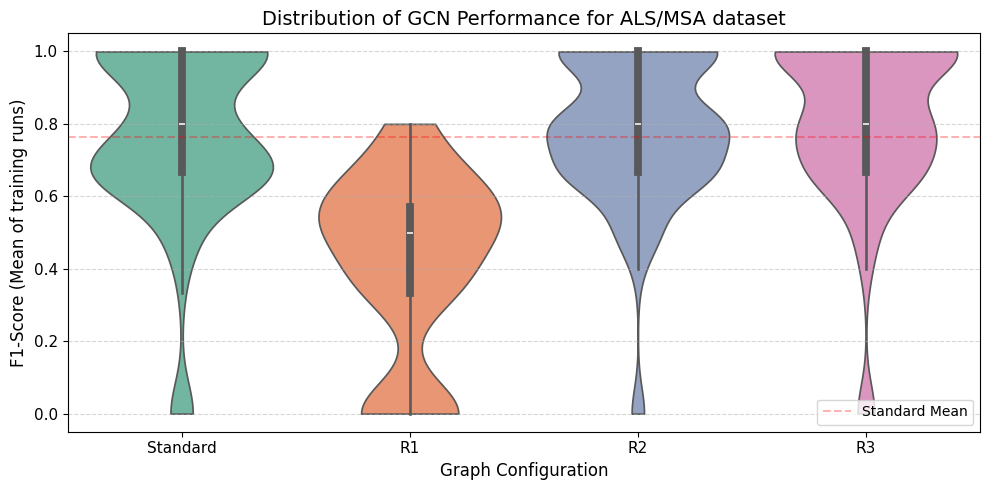

In [8]:
with open(f'./training_output/scores_ALS-MSA_transductive.json', 'r', encoding='utf-8') as f:
    scores = json.load(f)
    data = {
        'Standard': scores['GCN'],
        'R1': scores['R1'],
        'R2': scores['R2'],
        'R3': scores['R3']
    }

df_test = pd.DataFrame(data)
df_test_melted = df_test.melt(var_name='Condition', value_name='F1_Score')


plt.figure(figsize=(10, 5))

# Creazione del Violin Plot
sns.violinplot(
    data=df_test_melted,
    x='Condition', y='F1_Score',
    hue='Condition', legend=False, 
    palette='Set2', inner='box', cut=0)

# Formattazione
plt.title('Distribution of GCN Performance for ALS/MSA dataset', fontsize=14)
plt.ylabel('F1-Score (Mean of training runs)', fontsize=12)
plt.xlabel('Graph Configuration', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Media GCN baseline
baseline_mean = df['Standard'].mean()
plt.axhline(baseline_mean, color='red', linestyle='--', alpha=0.3, label='Standard Mean')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

TODOs:
- Controllare che R2, R3 facciano effettivamente qualcosa al ds di testing
- Fai test stat sul ds di testing e compara ai risultati del ds di training

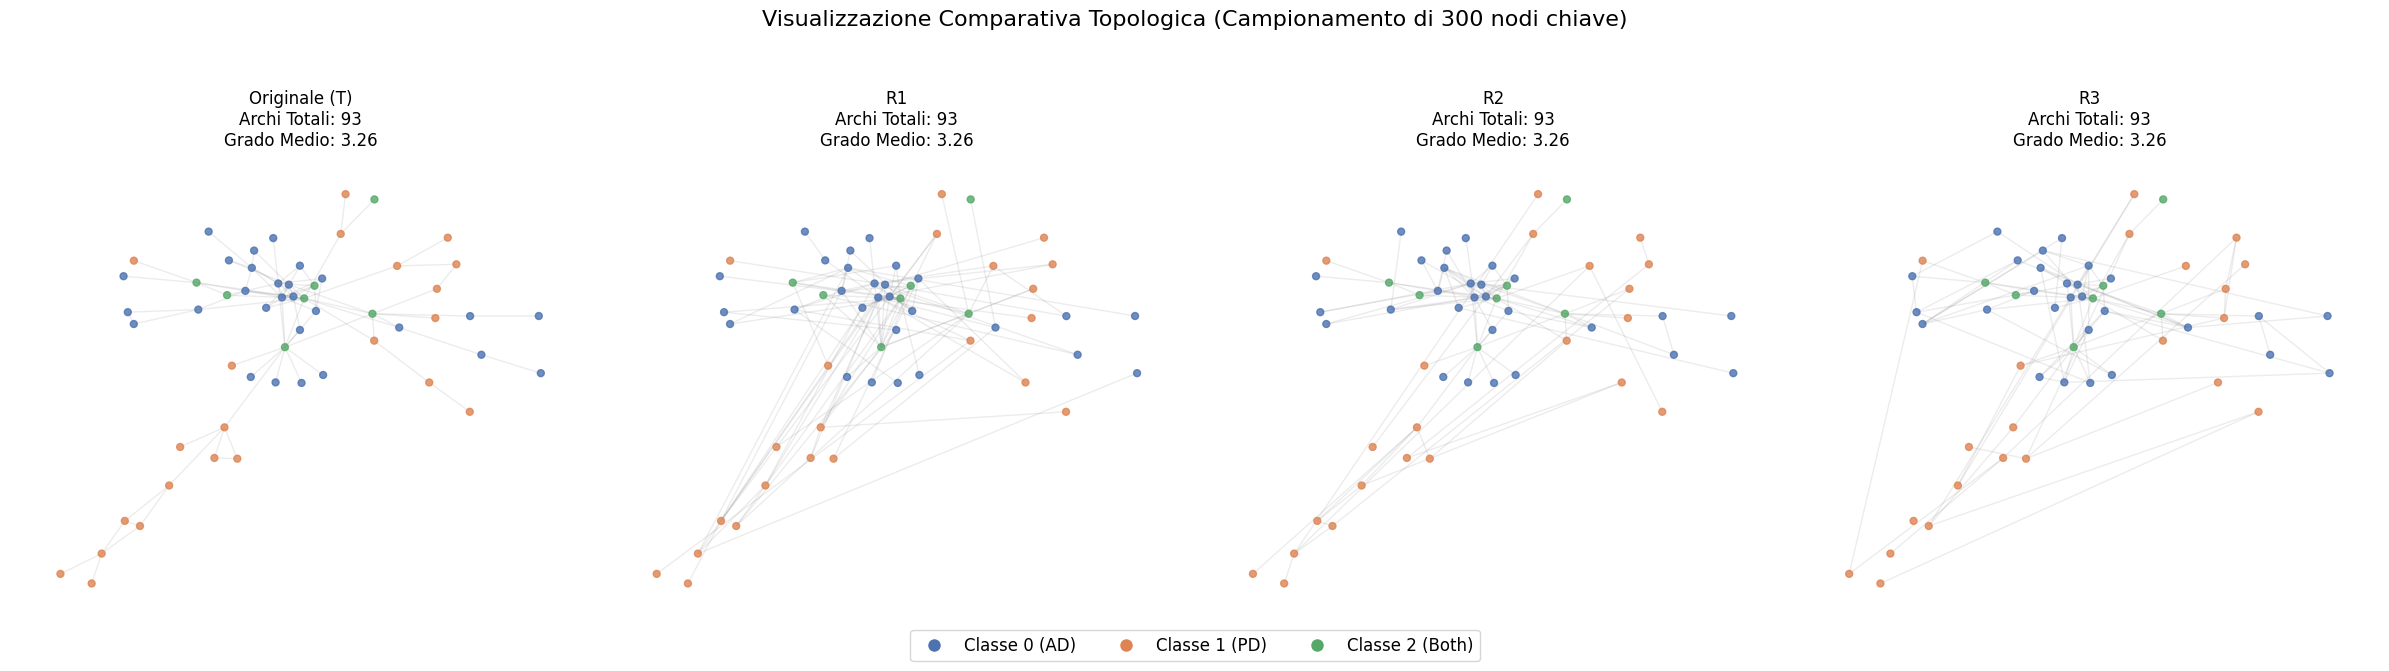

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import HeteroData

def plot_graph_comparison(test_ds: HeteroData, rewiring_strategies: dict, max_nodes_to_plot: int = 200, seed: int = 42):
    """
    Genera 4 subplot affiancati mostrando l'impatto visivo del rewiring sulla topologia del grafo.
    Campione un sottografo se il dataset è troppo grande, preservando la coerenza visiva.
    """
    # 1. Funzione helper per convertire HeteroData in un grafo NetworkX semplice (omogeneo)
    def to_nx_graph(hetero_data):
        G = nx.Graph()
        
        # Aggiungi nodi con la loro etichetta (classi 0, 1, 2)
        labels = hetero_data.y.cpu().numpy()
        for idx, l in enumerate(labels):
            G.add_node(idx, label=l)
            
        # Estrai e unisci gli edge index di tutte le relazioni eterogenee
        edge_index = hetero_data.edge_index
        edges = edge_index.t().cpu().numpy()
        G.add_edges_from(edges)
            
        return G

    # Genera i 4 grafi da plottare
    graphs_dict = {"Originale (T)": to_nx_graph(test_ds)}
    for label, rewire_fn in rewiring_strategies.items():
        # Generiamo un grafo sintetico usando il seed di riferimento
        t_synth = rewire_fn(test_ds, seed=seed)
        graphs_dict[label] = to_nx_graph(t_synth)

    # 2. Campionamento (Sottografo) se ci sono troppi nodi per evitare lag grafici
    # Usiamo il grafo originale come riferimento per mappare i nodi stabili da plottare
    ref_G = graphs_dict["Originale (T)"]
    if ref_G.number_of_nodes() > max_nodes_to_plot:
        # Seleziona i nodi con il grado più alto o semplicemente i primi N per consistenza
        nodes_to_keep = sorted(ref_G.nodes(), key=lambda n: ref_G.degree(n), reverse=True)[:max_nodes_to_plot]
    else:
        nodes_to_keep = list(ref_G.nodes())

    # 3. Calcolo del layout fisso (basato sul grafo originale) 
    # Mantenere le stesse posizioni XY permette di vedere l'effettivo "spostamento" degli archi
    pos = nx.spring_layout(ref_G.subgraph(nodes_to_keep), seed=seed)

    # Mappa dei colori basata sulle classi di test_ds.y (0: AD, 1: PD, 2: Overlap)
    color_map_nodes = {0: "#4c72b0", 1: "#dd8452", 2: "#55a868"}

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for idx, (title, G) in enumerate(graphs_dict.items()):
        ax = axes[idx]
        sub_G = G.subgraph(nodes_to_keep)
        
        # Estrai i colori dei nodi presenti nel sottografo
        node_colors = [color_map_nodes[sub_G.nodes[n]['label']] for n in sub_G.nodes()]
        
        # Calcolo di metriche veloci da stampare nel titolo del plot
        avg_degree = np.mean([d for _, d in G.degree()])
        num_edges = G.number_of_edges()
        
        # Disegno del grafo
        nx.draw_networkx_nodes(
            sub_G, pos, 
            node_size=25, 
            node_color=node_colors, 
            ax=ax, 
            alpha=0.8
        )
        nx.draw_networkx_edges(
            sub_G, pos, 
            alpha=0.15, 
            edge_color="gray", 
            ax=ax
        )
        
        ax.set_title(f"{title}\nArchi Totali: {num_edges}\nGrado Medio: {avg_degree:.2f}", fontsize=12)
        ax.axis("off")

    # Legenda personalizzata per le classi di proteine
    from matplotlib.lines import Line2D
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 0 (AD)', markerfacecolor='#4c72b0', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 1 (PD)', markerfacecolor='#dd8452', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 2 (Both)', markerfacecolor='#55a868', markersize=10)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(f"Visualizzazione Comparativa Topologica (Campionamento di {max_nodes_to_plot} nodi chiave)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

rewiring_strategies = {
    "R1": rewire_degree_preserving_complete,
    "R2": rewire_degree_preserving_stratified_connected,
    "R3": rewire_non_degree_preserving_stratified_complete
}

plot_graph_comparison(test_ds, rewiring_strategies, max_nodes_to_plot=300, seed=42)

- malattie cardiovascolari
- l'esperimento conferma che le topologie sono diverse. Andrebbe fatto per malattie con pathway molto simili
- 


1. Esperimento Transductive
- Addestramento transductive su un dataset appropriato, stessa pipeline di AD-PD, quindi test su sottografo.

2. Transfer Inductive
- Dopo punto 1, prova inferenza su AD-PD e confronta con esperimento inverso
- Fai anche con MLP (o comunque modello non topology-oriented)

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt
import json

with open('./training_output/scores_ALS-MSA_transductive.json', 'r', encoding='utf-8') as f:
    scores = json.load(f)
    data = {
        'Standard': scores['GCN'],
        'R1': scores['R1'],
        'R2': scores['R2'],
        'R3': scores['R3']
    }

df = pd.DataFrame(data)
df_melted = df.melt(var_name='Condition', value_name='F1_Score')

# Test di Kruskal-Wallis (non parametrico)
h_stat, p_kruskal = stats.kruskal(data['Standard'], data['R1'], data['R2'], data['R3'])

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_kruskal:.5e}")

# Analisi Post-hoc - Test di Dunn + correzione di Bonferroni
if p_kruskal < 0.05:
    print("\nDifferenza significativa rilevata")
else:
    print("\nNessuna differenza significativa tra i gruppi.")

# Calcolo dell'Effect Size (ϵ^2)
def calculate_epsilon_squared(h_stat, n):
    """Calcola l'Epsilon-quadrato per Kruskal-Wallis."""
    return h_stat / ((n**2 - 1) / (n + 1))

n_total = len(df_melted)
epsilon_sq = calculate_epsilon_squared(h_stat, n_total)

print(f"Epsilon-squared: {epsilon_sq:.4f}")

# Interpretazione automatica
if epsilon_sq >= 0.26:
    effect = "Large"
elif epsilon_sq >= 0.08:
    effect = "Medium"
else:
    effect = "Small"
print(f"L'entità dell'effetto è: {effect}")

Kruskal-Wallis H-statistic: 279.2042
p-value: 3.14796e-60

Differenza significativa rilevata
Epsilon-squared: 0.3494
L'entità dell'effetto è: Large


In [6]:
if p_kruskal < 0.05:
    print("Eseguendo il test di Dunn...")
    posthoc = sp.posthoc_dunn(df_melted, val_col='F1_Score', group_col='Condition', p_adjust='bonferroni')
    print(posthoc)
else:
    print(f"No posthoc - {p_kruskal:.3f}")

import pandas as pd
import numpy as np
from scipy import stats

ranks = stats.rankdata(df_melted['F1_Score'])
df_melted['Ranks'] = ranks

def get_dunn_z(group1, group2, df, val_col='F1_Score'):
    """ Calcola lo Z-score di Dunn con correzione per i legami (ties) """
    r1 = df[df['Condition'] == group1]['Ranks']
    r2 = df[df['Condition'] == group2]['Ranks']
    
    n1, n2 = len(r1), len(r2)
    N = len(df)
    
    # 1. Differenza medie dei ranghi
    mean_diff = np.abs(r1.mean() - r2.mean())
    
    # 2. Calcolo del fattore di correzione per i legami (Ties)
    # T = somma di (t^3 - t) per ogni gruppo di valori identici
    counts = df[val_col].value_counts().values
    tie_sum = np.sum(counts**3 - counts)
    tie_correction = 1 - (tie_sum / (N**3 - N))
    
    # 3. Errore standard corretto
    se = np.sqrt((N * (N + 1) / 12.0 - tie_sum / (12.0 * (N - 1))) * (1.0/n1 + 1.0/n2))
    
    z_score = mean_diff / se
    return z_score

def run_full_statistical_report(df_long):
    """Esegue l'analisi completa chiamando get_dunn_z per ogni coppia."""
    df = df_long.copy()
    
    # 1. Assegnazione dei ranghi globali (necessaria per get_dunn_z)
    df['Ranks'] = stats.rankdata(df['F1_Score'])
    
    groups = df['Condition'].unique()
    n_counts = df['Condition'].value_counts().to_dict()
    results = []

    # 2. Ciclo sui confronti a coppie
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            
            z_score = get_dunn_z(g1, g2, df)
            
            # Calcolo Effect Size r
            n_pair = n_counts[g1] + n_counts[g2]
            r_val = z_score / np.sqrt(n_pair)
            
            # Calcolo p-value grezzo
            # p_raw = 2 * (1 - stats.norm.cdf(z_score)) # Questo va in underflow
            p_raw = 2 * stats.norm.sf(z_score)
            
            results.append({
                'Comparison': f"{g1} vs {g2}",
                'Z_score': z_score,
                'r_effect': r_val,
                'p_raw': p_raw
            })
    # 3. Creazione DataFrame e Correzione
    report_df = pd.DataFrame(results)
    m = len(report_df)  # Numero di comparazioni
    report_df['p_adj'] = report_df['p_raw'].apply(lambda x: min(x * m, 1.0)) # Correzione di bonferroni inversa
    
    return report_df

# Esecuzione
stat_df = run_full_statistical_report(df_melted)
print("---\nDettaglio sulle comparazioni")
print(stat_df)

 

Eseguendo il test di Dunn...
                    R1            R2            R3      Standard
R1        1.000000e+00  3.108457e-39  8.910286e-48  1.521249e-36
R2        3.108457e-39  1.000000e+00  9.623540e-01  1.000000e+00
R3        8.910286e-48  9.623540e-01  1.000000e+00  3.628811e-01
Standard  1.521249e-36  1.000000e+00  3.628811e-01  1.000000e+00
---
Dettaglio sulle comparazioni
       Comparison    Z_score  r_effect         p_raw         p_adj
0  Standard vs R1  12.766101  0.638305  2.535415e-37  1.521249e-36
1  Standard vs R2   0.473523  0.023676  6.358399e-01  1.000000e+00
2  Standard vs R3   1.877277  0.093864  6.048019e-02  3.628811e-01
3        R1 vs R2  13.239624  0.661981  5.180761e-40  3.108457e-39
4        R1 vs R3  14.643377  0.732169  1.485048e-48  8.910286e-48
5        R2 vs R3   1.403753  0.070188  1.603923e-01  9.623540e-01
